# NeuroPrice — Phase 0: Foundations

Ce notebook valide les briques de base (GBM, Black-Scholes, Greeks) en réutilisant le package `neuroprice`.

In [2]:
from __future__ import annotations

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent
if (PROJECT_ROOT / "neuroprice").exists() and str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Fallback in case the notebook is started from the repo root already
ALT_ROOT = Path.cwd().resolve()
if (ALT_ROOT / "neuroprice").exists() and str(ALT_ROOT) not in sys.path:
    sys.path.insert(0, str(ALT_ROOT))


In [3]:
import numpy as np
import matplotlib.pyplot as plt

from neuroprice.stochastic.gbm import simulate_gbm_paths
from neuroprice.black_scholes.pricing import BlackScholesParams, call_price, put_price, put_call_parity_gap
from neuroprice.black_scholes.greeks import (
    call_delta, put_delta, gamma, vega, call_theta, put_theta, call_rho, put_rho
)


## 1) Simulation GBM (100 trajectoires)

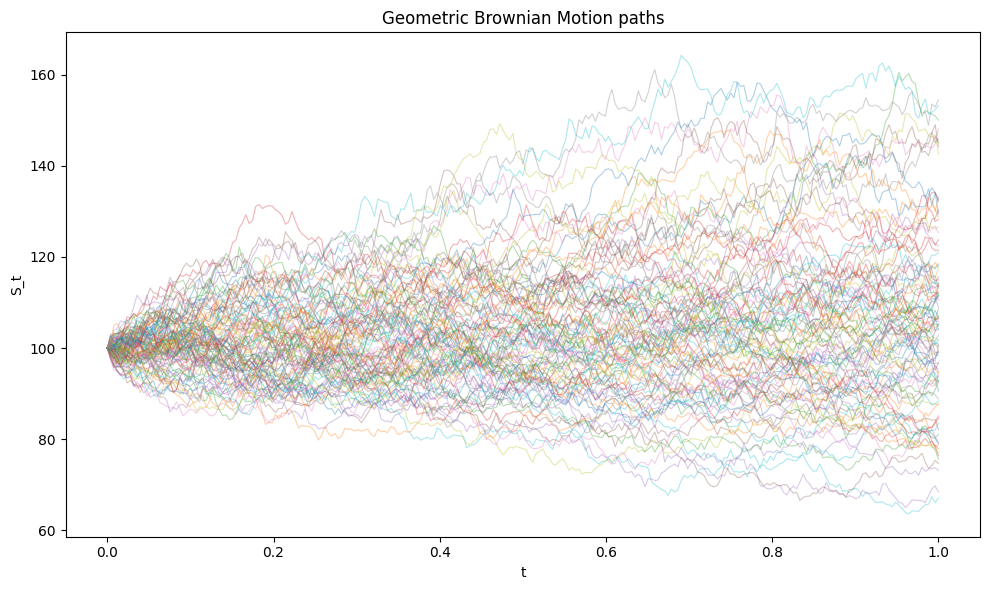

In [4]:
t, s = simulate_gbm_paths(s0=100.0, mu=0.05, sigma=0.20, T=1.0, n_steps=252, n_paths=100, seed=123)

fig, ax = plt.subplots(figsize=(10, 6))
for i in range(s.shape[0]):
    ax.plot(t, s[i], alpha=0.35, linewidth=0.8)
ax.set_xlabel('t')
ax.set_ylabel('S_t')
ax.set_title('Geometric Brownian Motion paths')
fig.tight_layout()
plt.show()


## 2) Black-Scholes: prix Call/Put + parité Put-Call

In [5]:
p = BlackScholesParams(S=100.0, K=105.0, r=0.05, sigma=0.20, T=1.0)

c = call_price(p)
put = put_price(p)
gap = put_call_parity_gap(p)

print('Call:', c)
print('Put :', put)
print('Put-call parity gap (should be ~0):', gap)


Call: 8.021352235143176
Put : 7.9004418077181455
Put-call parity gap (should be ~0): 0.0


## 3) Greeks analytiques

In [6]:
print('Call delta:', call_delta(p))
print('Put delta :', put_delta(p))
print('Gamma    :', gamma(p))
print('Vega     :', vega(p))
print('Call theta:', call_theta(p))
print('Put theta :', put_theta(p))
print('Call rho  :', call_rho(p))
print('Put rho   :', put_rho(p))


Call delta: 0.5422283335848053
Put delta : -0.45777166641519473
Gamma    : 0.019835261904213263
Vega     : 39.67052380842653
Call theta: -6.277126437009521
Put theta : -1.283171958380772
Call rho  : 46.20148112333735
Put rho   : -53.677608449237624
